# W04A - Harmonic Oscillator 1D

### Task 1 - repeat Metropolis monte carlo

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class Spring ():
    def __init__(self, k=1, x0=0):
        self.k = k
        self.x0 = x0

    # to be used in the MC
    def potential_energy(self, x):
        return 0.5 * self.k * (x - self.x0)**2

    # to be used in the MD
    def force(self, x):
        return -self.k * (x - self.x0)

In [4]:
class MetropolisMonteCarlo():
    def __init__(self, calc, kT=0.15, xmin=-3, xmax=3, Nsamples=100000):
        self.calc = calc
        self.kT = kT
        self.xmin = xmin
        self.xmax = xmax
        self.x = self.calc.x0
        self.Nsamples = Nsamples

        self.xspace = np.linspace(self.xmin, self.xmax, 100)
        self.energy = self.potential_energy(self.calc.x0)
        self.energies = self.potential_energy(self.xspace)
        #self.force = self.calc.force(self.xspace)

        self.counts, self.bin_edges = self.run_Metropolis_Monte_Carlo()
        self.bin_centers = 0.5 * (self.bin_edges[:-1] + self.bin_edges[1:])

        self.p_exact = np.exp(-self.energies / self.kT)
        self.p_exact /= np.trapezoid(self.p_exact, self.xspace)   # divide by true area

    def potential_energy(self, x):
        return self.calc.potential_energy(x)

    def proposed_x(self):
        return np.random.rand() * abs(self.xmax - self.xmin) + self.xmin
    
    def step(self):
        proposed_x = self.proposed_x()
        proposed_energy = self.potential_energy(proposed_x)
        delta_V = proposed_energy - self.energy
        acceptance_probability = min(1, np.exp(-delta_V / self.kT))  # using P(x')/P(x) = exp(-E'/kT)/exp(E/kT) = exp(-delta_E/kT)
        # a clever way to choose randomly given a probability
        # if acceptance_probability=0.4, it is chosen 40% of times.
        if np.random.rand() < acceptance_probability:
            self.x = proposed_x
            self.energy = proposed_energy
    
    def run_Metropolis_Monte_Carlo(self):
        self.visited_states = [self.x]  # get initial position too
        for _ in range(self.Nsamples):
            self.step()
            self.visited_states.append(self.x)
        counts, bin_edges = np.histogram(self.visited_states, bins=abs(self.xmax-self.xmin)*8+1, range=(self.xmin, self.xmax))
        probabilites = counts/np.sum(counts)  # get mmc probabilites
        return probabilites, bin_edges

    def thermal_avg_exact(self):
        # should be 1/2 kT for simple harmonic oscillator
        x = self.xspace
        V_pot = self.potential_energy(x)

        boltzmann = np.exp(-V_pot/self.kT)

        numerator = np.trapezoid(V_pot*boltzmann, x)
        denominator = np.trapezoid(boltzmann, x)

        return numerator/denominator

    def thermal_avg(self):
        return np.mean([self.potential_energy(x) for x in self.visited_states])

    def plot(self, ax):
        bin_width = self.bin_edges[1] - self.bin_edges[0]
        P = self.counts/bin_width
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='C0', alpha =0.25)
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='None', edgecolor ='k')
        ax.set_title(r'$\langle V\rangle_{exact}=$'+f'{self.thermal_avg_exact():.3f}'+', 'r'$\langle V\rangle=$'+f'{self.thermal_avg():.3f}')
        ax.plot(self.xspace, self.p_exact, 'k')
        ax.plot(self.xspace, self.calc.potential_energy(self.xspace), 'k')
        ax.text(0, 2.5, r'$kT=$'+f'{self.kT}', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
        ax.set_ylim(0,3)

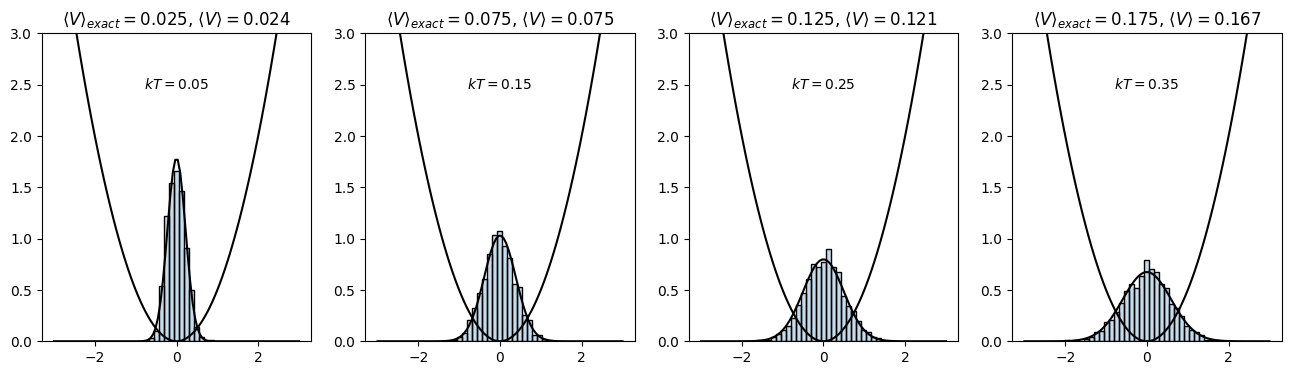

In [5]:
spring = Spring()

fig, axes = plt.subplots(1,4,figsize=(16,4))

for kT, ax in zip([0.05, 0.15, 0.25, 0.35],axes):
    met_mc = MetropolisMonteCarlo(spring, kT=kT, Nsamples=10_000)
    met_mc.plot(ax)

### Task 2 - Implement velocity Verlet algorithm with constant energy MD

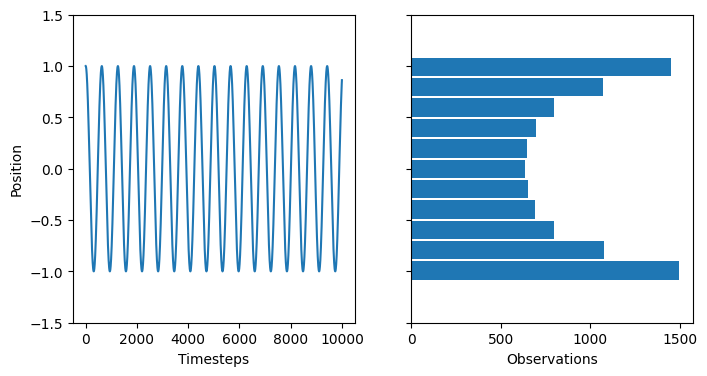

In [6]:
def velocity_verlet(mdsys, N=100):
    rs = []
    for _ in range(N):
        dt = 0.01
        r = mdsys.get_position()
        v = mdsys.get_velocity()
        a_t = mdsys.force() # assume m=1

        # 1. update position
        r += v*dt + 1/2*a_t*dt**2
        mdsys.set_position(r)

        # 2. evaluate force and acceleration at new step
        a_t_dt = mdsys.force() # for harmonic osciallor F = -kx

        # 3. velocity update
        v += 1/2 * (a_t + a_t_dt)*dt
        mdsys.set_velocity(v)
        rs.append(r)
    return rs


class  MolDynSystem ():
    def __init__(self, calc, x=0, kT=0.15):
        self.calc = calc
        self.x = x
        self.v = 0
        self.kT = kT
        self.k = self.calc.k
        self.x0 = self.calc.x0

    def potential_energy(self):
        return self.calc.potential_energy(self.x)
    
    def force(self):
        return self.calc.force(self.x)
    
    def get_position(self):
        return self.x
    
    def set_position(self, x):
        self.x = x

    def get_velocity(self):
        return self.v
    
    def set_velocity(self, v):
        self.v = v

    def thermal_avg(self, xs):
        return np.mean([self.calc.potential_energy(x) for x in xs])

    def thermal_fluctuations(self, xs):
        V = np.array([self.calc.potential_energy(x) for x in xs])

        V_avg = np.mean(V)
        V2_avg = np.mean(V**2)

        return (V2_avg - V_avg**2) / self.kT**2


# start the oscillator out somewhere out of equilibrium (it defaults to zero velocity)
md = MolDynSystem(spring, x=1)
# Now get the positions from the molecular dynamics simulation
timesteps = 10000
xs = velocity_verlet(md, N=timesteps)
# plot them
fig, axes = plt.subplots(1,2,figsize=(8,4), sharey=True)

axes[0].plot(np.arange(timesteps), xs)
axes[0].set_ylabel('Position')
axes[0].set_xlabel('Timesteps')

N_bins = 11
bin_shift = abs(max(xs)-min(xs))/N_bins/2 # to center bins
counts, bin_edges = np.histogram(xs, bins=N_bins, range=(min(xs)-bin_shift, max(xs)+bin_shift))
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
#P = counts/bin_width
axes[1].barh(bin_centers, counts, height=bin_width*0.9)
#axes[1].hist(xs, bins=11, rwidth=0.9, orientation="horizontal")
axes[1].set_xlabel('Observations')

for ax in axes:
    ax.set_ylim(-1.5,1.5)


### Task 3 - Constant temperature MD

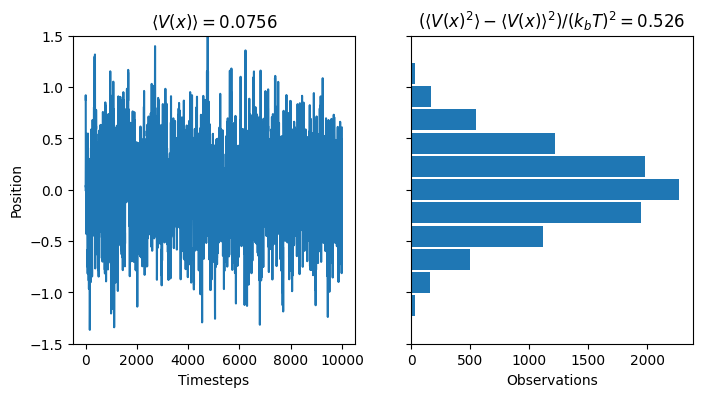

In [7]:
def andrea_anderson_thermostat(md):
    sigma = np.sqrt(md.kT) #/m is omitted, m=1
    v = np.random.normal(0, sigma)
    md.set_velocity(v)


md = MolDynSystem(spring, x=1)
xs = []
for _ in range(10000):
    # do 50 constant energy steps
    x = velocity_verlet(md, N=50)
    # add the final position to your sample
    xs.append(x[-1])
    # apply the thermostat
    andrea_anderson_thermostat(md)

fig, axes = plt.subplots(1,2,figsize=(8,4), sharey=True)

axes[0].plot(np.arange(timesteps), xs)
axes[0].set_ylabel('Position')
axes[0].set_xlabel('Timesteps')
axes[0].set_title(r'$\langle V(x)\rangle=$'+f'{md.thermal_avg(xs):.3g}')

N_bins = 15
bin_shift = abs(max(xs)-min(xs))/N_bins/2 # to center bins
counts, bin_edges = np.histogram(xs, bins=N_bins, range=(min(xs)-bin_shift, max(xs)+bin_shift))
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
axes[1].barh(bin_centers, counts, height=bin_width*0.9)
axes[1].set_xlabel('Observations')
axes[1].set_title(r'$(\langle V(x)^2\rangle-\langle V(x)\rangle^2)/(k_bT)^2=$'+f'{md.thermal_fluctuations(xs):.3g}')

for ax in axes:
    ax.set_ylim(-1.5,1.5)

# W04B - Double Well Potential

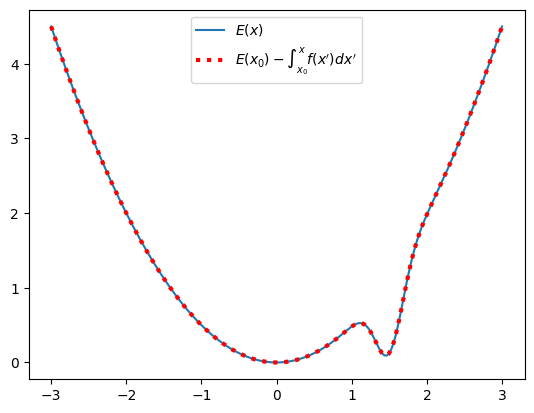

In [8]:
# def potential(x, x0=0, k=1, A=-1, x1=1.5, lamb=0.25):
#     return 

fig, ax = plt.subplots()
# xs = np.linspace(-3.2, 3.2, 200)
# ax.plot(xs, potential(xs))

class  DoubleWell ():
    def __init__(self ,k=1, x0= 0, A=-1, x1=1.5 , l=0.25, xmin=-3, xmax=3):
        self.k = k
        self.x0 = x0
        self.A = A
        self.x1 = x1
        self.l = l

        self.xmin = xmin
        self.xmax = xmax
        self.xspace = np.linspace(self.xmin, self.xmax, 200)
        self.energies = self.potential_energy(self.xspace)
        self.forces = self.force(self.xspace)
        self.integrated_forces = self.integrated_force(self.xspace)

    def potential_energy (self , x):
        return 1/2 * self.k * (x-self.x0)**2 + self.A * np.exp(-(x-self.x1)**2/self.l/self.l)
    
    def force(self, x):
        # F = -dU/dx
        return -self.k*(x-self.x0)+(2*self.A*(x-self.x1)*np.exp(-(x-self.x1)**2/self.l/self.l))/self.l/self.l

    def integrated_force(self, x):
        integrated = []
        for i in range(0, len(x)):
            integration_space = np.linspace(self.x0, x[i])
            force_space = self.force(integration_space)
            integral = np.trapezoid(force_space, integration_space)
            integrated.append(self.potential_energy(self.x0) - integral)
        return integrated

    def plot(self, ax):
        ax.plot(self.xspace, self.energies, label=r'$E(x)$')
        ax.plot(self.xspace, self.integrated_forces, 'r:', linewidth=3, label=r"$E(x_0)-\int_{x_0}^{x}f(x')dx'$")
        ax.legend()
    
double_well = DoubleWell()
double_well.plot(ax)


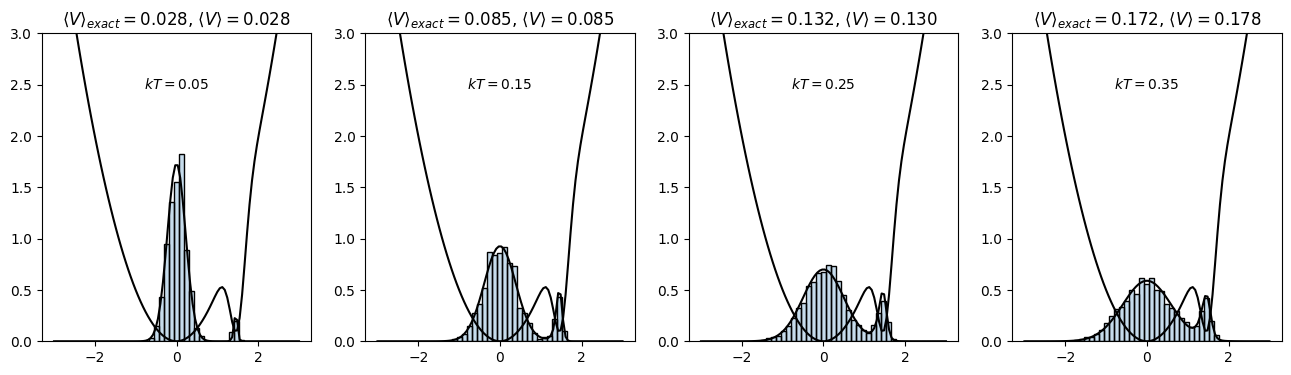

In [9]:
fig, axes = plt.subplots(1,4,figsize=(16,4))

for kT, ax in zip([0.05, 0.15, 0.25, 0.35],axes):
    metro_mc = MetropolisMonteCarlo(double_well, kT=kT, Nsamples=10_000)
    metro_mc.plot(ax)

Now using velocity verlet with thermalization updates (andrea_anderson_thermostat) to get a sample of positions:

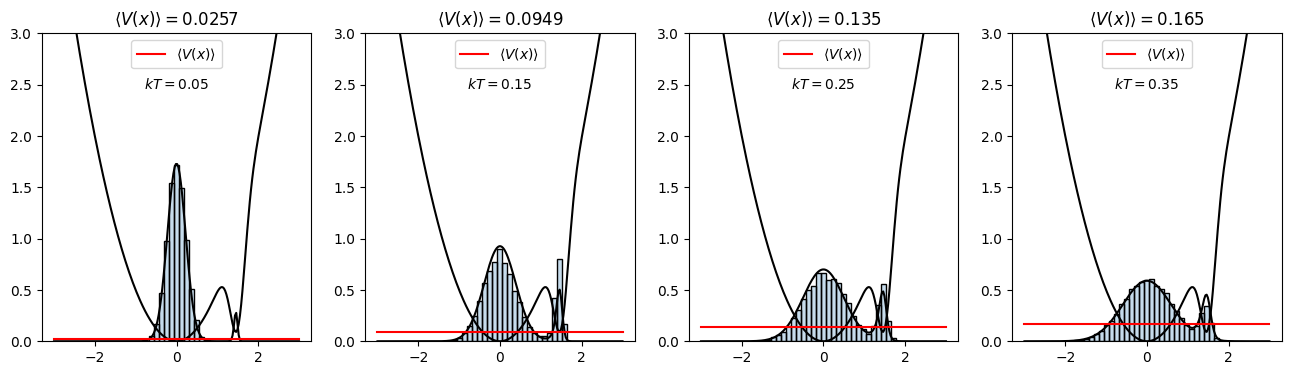

In [10]:
fig, axes = plt.subplots(1,4,figsize=(16,4))

for ax, kT in zip(axes, [0.05,0.15,0.25,0.35]):
    # start the oscillator out somewhere out of equilibrium (it defaults to zero velocity)
    md = MolDynSystem(double_well, x=double_well.x0, kT=kT)
    # Now get the positions from the molecular dynamics simulation
    timesteps = 10000
    xs = []
    for step in range(timesteps):
        # do 50 constant energy steps
        x = velocity_verlet(md, N=50)
        # add the final position to your sample
        xs.append(x[-1])
        # apply the thermostat
        andrea_anderson_thermostat(md)

    xmin = double_well.xmin
    xmax = double_well.xmax

    counts, bin_edges = np.histogram(xs, bins=abs(xmax-xmin)*8+1, range=(xmin, xmax))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    probabilities = counts/sum(counts)
    P = probabilities/bin_width

    xspace = np.linspace(xmin, xmax, 200)
    ax.bar(bin_centers, P, width=bin_width, facecolor ='C0', alpha =0.25)
    ax.bar(bin_centers, P, width=bin_width, facecolor ='None', edgecolor ='k')
    ax.plot(xspace, double_well.potential_energy(xspace), 'k')

    p_exact = np.exp(-double_well.potential_energy(xspace) / kT)
    p_exact /= np.trapezoid(p_exact, xspace)   # divide by true area
    ax.plot(xspace, p_exact, 'k')
    
    ax.set_title(r'$\langle V(x)\rangle=$'+f'{md.thermal_avg(xs):.3g}')
    ax.plot(xspace, [md.thermal_avg(xs)]*len(xspace), 'r-', label=r'$\langle V(x)\rangle$')
    ax.legend(loc='upper center')
    ax.text(0, 2.5, r'$kT=$'+f'{kT}', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
    ax.set_ylim(0,3)

Repeating with initial position at $x=x_1$

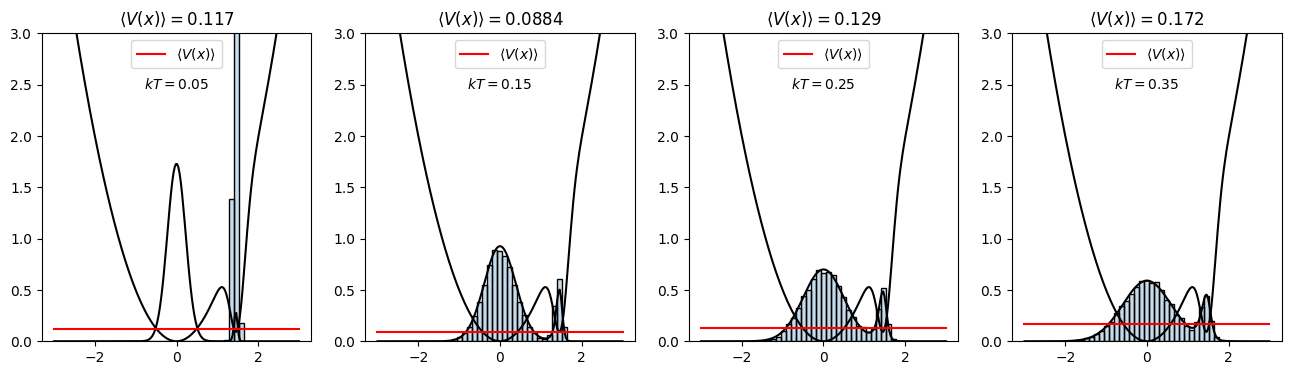

In [11]:
fig, axes = plt.subplots(1,4,figsize=(16,4))

for ax, kT in zip(axes, [0.05,0.15,0.25,0.35]):
    # start the oscillator out somewhere out of equilibrium (it defaults to zero velocity)
    md = MolDynSystem(double_well, x=double_well.x1, kT=kT)
    # Now get the positions from the molecular dynamics simulation
    timesteps = 10000
    xs = []
    for step in range(timesteps):
        # do 50 constant energy steps
        x = velocity_verlet(md, N=50)
        # add the final position to your sample
        xs.append(x[-1])
        # apply the thermostat
        andrea_anderson_thermostat(md)

    xmin = double_well.xmin
    xmax = double_well.xmax

    counts, bin_edges = np.histogram(xs, bins=abs(xmax-xmin)*8+1, range=(xmin, xmax))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    probabilities = counts/sum(counts)
    P = probabilities/bin_width

    xspace = np.linspace(xmin, xmax, 200)
    ax.bar(bin_centers, P, width=bin_width, facecolor ='C0', alpha =0.25)
    ax.bar(bin_centers, P, width=bin_width, facecolor ='None', edgecolor ='k')
    ax.plot(xspace, double_well.potential_energy(xspace), 'k')

    p_exact = np.exp(-double_well.potential_energy(xspace) / kT)
    p_exact /= np.trapezoid(p_exact, xspace)   # divide by true area
    ax.plot(xspace, p_exact, 'k')
    
    ax.set_title(r'$\langle V(x)\rangle=$'+f'{md.thermal_avg(xs):.3g}')
    ax.plot(xspace, [md.thermal_avg(xs)]*len(xspace), 'r-', label=r'$\langle V(x)\rangle$')
    ax.legend(loc='upper center')
    ax.text(0, 2.5, r'$kT=$'+f'{kT}', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
    ax.set_ylim(0,3)

"Discuss the implications of the thermally averaged potential energy"

A high <V(x)> with at low T provides an indication that distribution is not correctly sampled, and that we may be trapped in a local minima.

# W04C - Constant Energy MD in many-D

In [12]:
from week04 import Morse

morse = Morse()
float(morse.potential_energy([[0 ,0] ,[1 ,0]]))
# -1.5

-1.5

-4.024099953848151
-4.4999999716876395


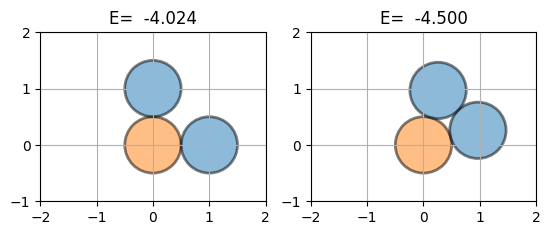

In [13]:
from week04 import nice_plot, relax
from week04 import AtomicCluster as AtomicClusterBase

pos = [[0, 0], [1,0], [0,1]]
static = [True, False, False]
atomic_cluster = AtomicClusterBase(morse, pos=pos ,static=static)

fig, axes = plt.subplots(1,2)

print(float(atomic_cluster.potential_energy))
atomic_cluster.draw(axes[0])

relax(atomic_cluster)

print(float(atomic_cluster.potential_energy))
atomic_cluster.draw(axes[1])

for ax in axes:
    nice_plot(ax)


-4.024099953848151
-4.4999999716876395


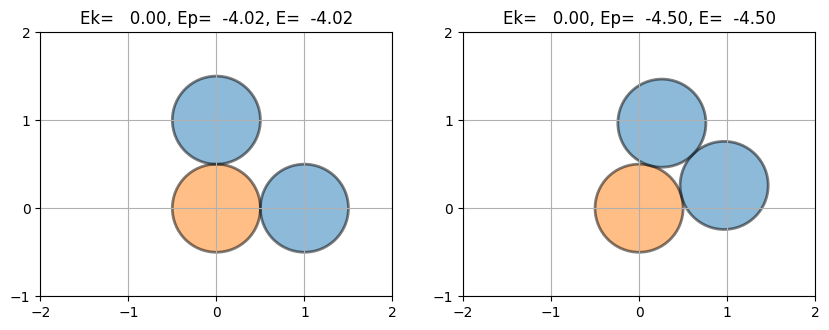

In [14]:
class AtomicCluster(AtomicClusterBase):
    def __init__(self, *args, kT=0.15, **kwargs):
        super().__init__(*args, **kwargs)
        self.velocities = np.zeros(self.pos.shape)
        self.kT = kT

    @property
    def kinetic_energy(self):
        return 0.5 * np.sum(self.velocities**2)

    def set_velocities(self, velocities):
        self.velocities = np.where(self.filter, 0, velocities)

    def get_velocities(self):
        return self.velocities.copy()

    def draw_title(self, ax):
        ek = self.kinetic_energy
        ep = self.potential_energy
        etot = ek + ep
        ax.set_title(f'Ek={ek:7.2f}, Ep={ep:7.2f}, E={etot:7.2f}')

    def draw(self, *args, center=False, **kwargs):
        if center:
            mean_pos = np.mean(self.pos,axis=0)
            self.pos -= mean_pos
            super().draw(*args, **kwargs)
            self.pos += mean_pos
        else:
            super().draw(*args, **kwargs)



atomic_cluster = AtomicCluster(morse, pos=pos, static=static)

fig, axes = plt.subplots(1,2, figsize=(10,5))

print(float(atomic_cluster.potential_energy))
atomic_cluster.draw(axes[0])
atomic_cluster.draw_title(axes[0])

relax(atomic_cluster)

print(float(atomic_cluster.potential_energy))
atomic_cluster.draw(axes[1])
atomic_cluster.draw_title(axes[1])

for ax in axes:
    nice_plot(ax)


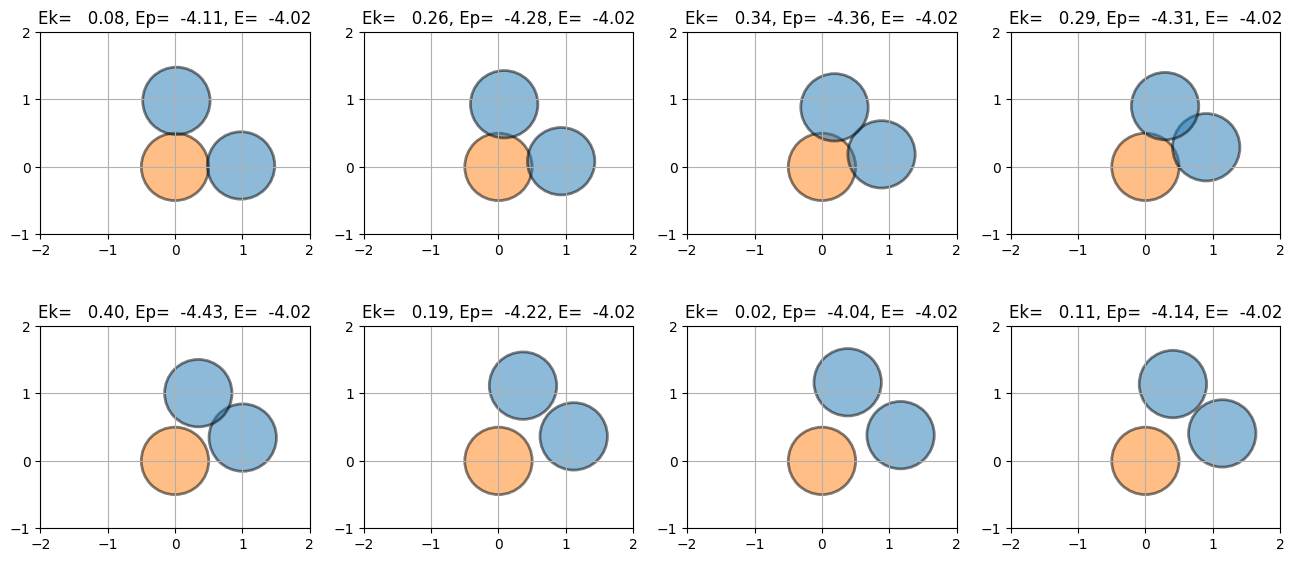

In [15]:
def velocity_verlet_sim(mdsys, N=50, timesteps=1):
    for steps in range(timesteps):
        for _ in range(N):
            dt = 0.01
            r = mdsys.get_positions()
            v = mdsys.get_velocities()
            a_t = mdsys.forces # assume m=1

            # 1. update position
            r += v*dt + 1/2*a_t*dt**2
            mdsys.set_positions(r)

            # 2. evaluate force and acceleration at new step
            a_t_dt = mdsys.forces # for harmonic osciallor F = -kx

            # 3. velocity update
            v += 1/2 * (a_t + a_t_dt)*dt
            mdsys.set_velocities(v)

fig, axes = plt.subplots(2,4,figsize=(16,7))
for ax, t in zip(axes.flatten(), np.arange(1,9)):
    atomic_cluster = AtomicCluster(morse, pos=pos, static=static)
    velocity_verlet_sim(atomic_cluster, N=20, timesteps=t)
    atomic_cluster.draw(ax)
    atomic_cluster.draw_title(ax)
    nice_plot(ax)
        

In the simulation, we how the free atoms start to move together by attraction and gain velocity.

As they get close to equilibrium, they still have high velocity (conservation of energy). They therefore bounce back and drift away from the static atom.

Now make an animation of it:

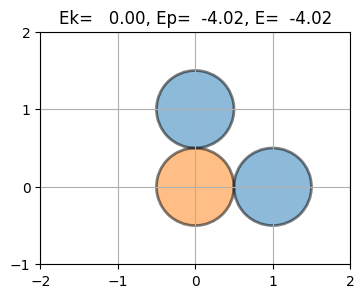

In [16]:
atomic_cluster = AtomicCluster(morse, pos=pos, static=static)
fig, ax = plt.subplots(figsize =(4,4))
atomic_cluster.draw(ax)
nice_plot(ax)

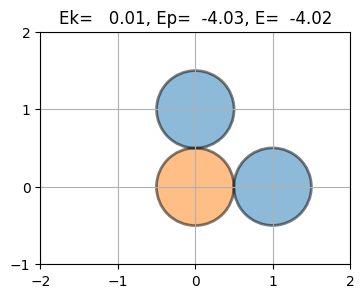

In [17]:
from matplotlib import animation
plt.rc('animation', html='jshtml')

N = 100
Nbefore = 10
Nafter = 10

def update(i):
    if Nbefore <= i < Nbefore + N:
        velocity_verlet_sim(atomic_cluster, N=5)
    drawing_object = atomic_cluster.draw(ax)
    return []# drawing_object

update(20)
fig

In [18]:
anim = animation.FuncAnimation(fig, update, frames=Nbefore + N + Nafter, interval=50, blit=True)
# anim

In [19]:
writer = animation.writers['pillow'](fps=10) # frames per second
anim.save('atoms.gif', writer=writer)


# W04D - Evaporation

In [20]:
def andrea_anderson_thermostat_sim(ac):
    sigma = np.sqrt(ac.kT) #/m is omitted, m=1
    # print(len(ac.pos))
    velocities = [[np.random.normal(0, sigma), np.random.normal(0, sigma)] \
                   for _ in range(len(ac.pos))]
    ac.set_velocities(velocities)


def evaporation_sim(ac, axes, N_samples=500):
    # run 500 samples, plot, and then another 500 samples.
    energies = []
    for i, ax in enumerate(axes.flatten()):
        for step in range(N_samples):
            # apply the thermostat
            andrea_anderson_thermostat_sim(atomic_cluster)
            # do 50 constant energy steps
            velocity_verlet_sim(atomic_cluster, N=50)
            # save energy at step
            etot = atomic_cluster.kinetic_energy + atomic_cluster.potential_energy
            energies.append(etot)
        #calculate heat capacity from energy fluctuations
        C_v = (np.mean(np.array(energies)**2) - np.mean(energies)**2)/atomic_cluster.kT**2
        atomic_cluster.draw(ax, center=True)
        ax.set_title(r'$N_{samples}=$'+f'{len(energies)}, '+r'$C_v=$'+f'{C_v:.3g}')
        nice_plot(ax)



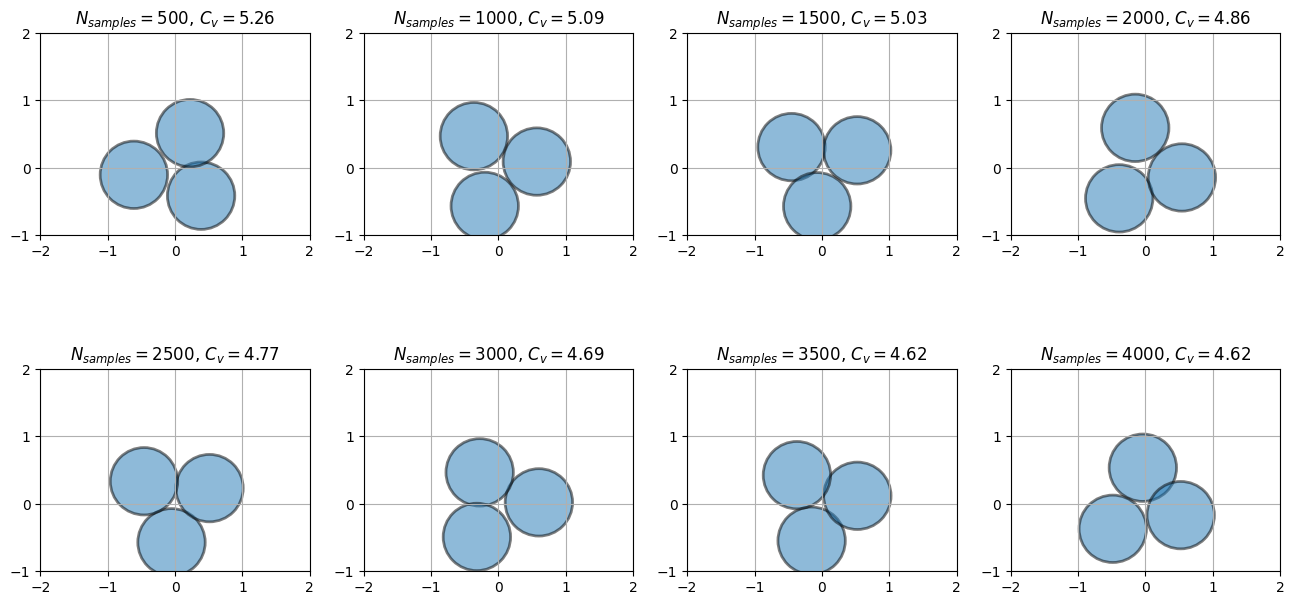

In [21]:
fig, axes = plt.subplots(2,4,figsize=(16,8))
pos = [[0,0],[1,0],[0,1]]
static = [False]*3
atomic_cluster = AtomicCluster(morse, pos=pos, static=static, kT=0.025)

evaporation_sim(atomic_cluster, axes)
    

Now with kT=0.25

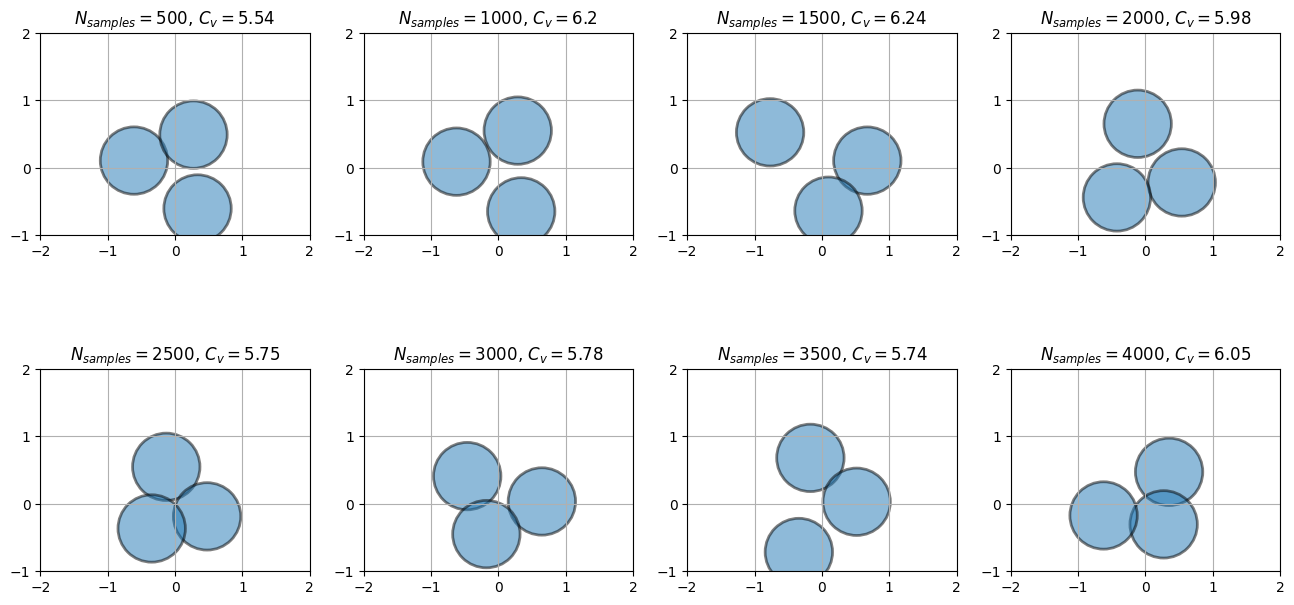

In [97]:
fig, axes = plt.subplots(2,4,figsize=(16,8))
pos = [[0,0],[1,0],[0,1]]
static = [False]*3
atomic_cluster = AtomicCluster(morse, pos=pos, static=static, kT=0.25)

evaporation_sim(atomic_cluster, axes)

Try and make a movie

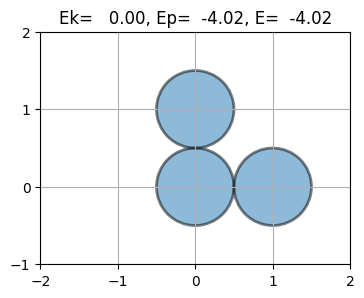

In [40]:
fig, ax = plt.subplots(figsize =(4,4))
atomic_cluster = AtomicCluster(morse, pos=pos, static=static, kT=0.25)
atomic_cluster.draw(ax)
nice_plot(ax)

In [41]:
from matplotlib import animation
plt.rc('animation', html='jshtml')

Nsamples = 4000
draw_every = 10

energies = []
def update(i):
    for _ in range(draw_every):
        andrea_anderson_thermostat_sim(atomic_cluster)
        velocity_verlet_sim(atomic_cluster, N=5)
        etot = atomic_cluster.kinetic_energy + atomic_cluster.potential_energy
        energies.append(etot)

        #drawing_object = atomic_cluster.draw(ax, center=True)
        atomic_cluster.draw(ax, center=True)
        C_v = (np.mean(np.array(energies)**2) - np.mean(energies)**2)/atomic_cluster.kT**2
        ax.set_title(r'$N_{samples}=$'+f'{len(energies)}, '+r'$C_v=$'+f'{C_v:.3g}')

    return []# drawing_object

#update(1)
#fig

In [42]:
anim = animation.FuncAnimation(fig, update, frames=Nsamples//draw_every, interval=50, blit=False)
# anim

In [43]:
writer = animation.writers['pillow'](fps=10) # frames per second
anim.save('free_atoms.gif', writer=writer)

### Task 3 - simulate over a wide range of temperatures

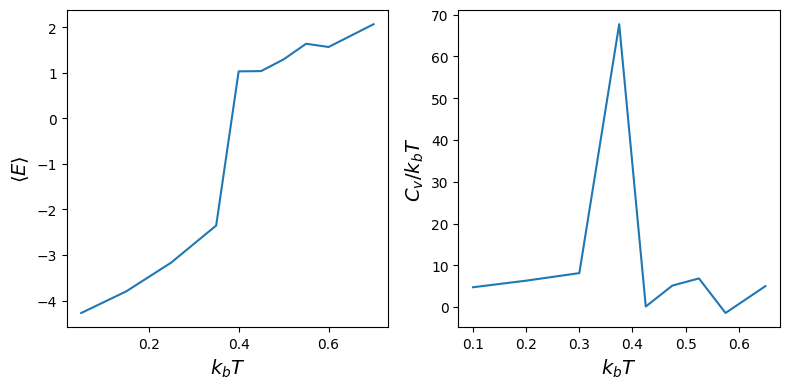

In [181]:
mean_energies = []
N_samples = 2500
#kTs = np.arange(0.05, 0.65, step=0.5)
kTs = np.array([0.05, 0.15, 0.25, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7])
for kT in kTs:
    atomic_cluster = AtomicCluster(morse, pos=pos, static=static, kT=kT)
    energies = []
    for step in range(N_samples):
        # apply the thermostat
        andrea_anderson_thermostat_sim(atomic_cluster)
        # do 50 constant energy steps
        velocity_verlet_sim(atomic_cluster, N=50)
        # save energy at step
        if step > 500: #skip while the system is equilibrating
            etot = atomic_cluster.kinetic_energy + atomic_cluster.potential_energy
            energies.append(etot)
    mean_energies.append(np.mean(energies))

fig, axes = plt.subplots(1,2,figsize=(8,4))
mean_energies = np.array(mean_energies)
kT_mids = (kTs[:-1]+kTs[1:])/2
dEdT = (mean_energies[1:]-mean_energies[:-1])/(kTs[1:]-kTs[:-1])
axes[0].plot(kTs, mean_energies)
axes[1].plot(kT_mids, dEdT)
axes[0].set_ylabel(r'$\langle E \rangle$', fontsize=14)
axes[1].set_ylabel(r'$C_v/k_b T$', fontsize=14)
for ax in axes:
    ax.set_xlabel(r'$k_b T$', fontsize=14)
fig.tight_layout()

As the temperature increases, so does the mean energy. At some point, the temperature gets so high that the energy of the molecule is large enough to evaporate it, i.e. break the bonds between the atoms. 

When the energy grows, the state moves up in the morse potential, until the distance between atoms goes toward infinite. That is the steep rise we see on the left graph.

This energy barrier is represented as a large peak in heat capacity. After the bonds break, the heat capacity drops. It drops further than the initial state, since there are no strong bonds between the atoms. That is not easily seen here though.

# W04E - Simulated annealing

In [44]:
from week04 import Morse
from week04 import AtomicCluster as AtomicClusterBase
from week04 import relax
morse = Morse()
class AtomicCluster(AtomicClusterBase):
    def __init__(self,*args, kT =0.15, title=None, ** kwargs):
        super().__init__(*args,** kwargs)
        self.velocities = np.zeros(self.pos.shape)
        self.kT = kT
        self.title = title

    @property
    def kinetic_energy(self):
        return 0.5 * np.sum(self.velocities**2)
    
    def set_velocities(self, velocities):
        self.velocities = np.where(self.filter, 0, velocities)

    def get_velocities(self):
        return self.velocities.copy()
    
    def draw_title(self,ax):
        if self.title:
            title = self.title + f', E={(self.potential_energy+self.kinetic_energy):.2f}'
        else:
            title = f'E={(self.potential_energy+self.kinetic_energy):.2f}'
        ax.set_title(title)

(-6.0, 5.0)

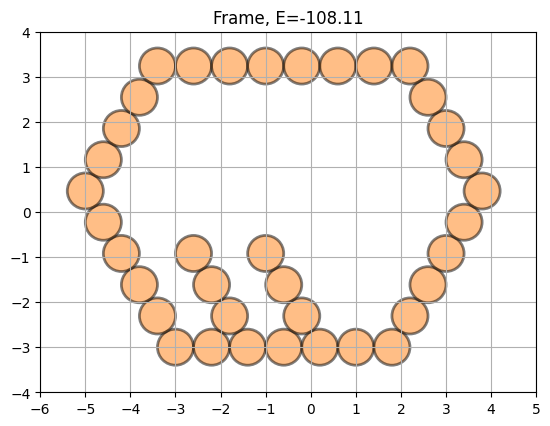

In [45]:
def create_initial_cluster(N=5, kT=0.15):
    pos = []
    a = np.array ([1 ,0]) *0.8
    b = np.array ([0.5 , np.sqrt (3) /2]) *0.8
    coords = [(0 ,0) ,(1,0) ,(2,0) ,(3,0) ,(4,0) ,(5,0) ,(6,0),
             (-1,1) ,(1,1) ,(3,1) ,(6,1),
             (-2,2) ,(0,2) ,(2,2) ,(6,2),
             (-3,3) ,(-1,3) ,(1,3) ,(6,3),
             (-4,4) ,(6,4) ,(-5,5) ,(6,5),
             (-5,6) ,(5,6) ,(-5,7) ,(4,7),
             (-5,8) ,(3,8),
             (-5,9) ,(-4,9) ,(-3,9) ,(-2,9) ,(-1,9) ,(0,9) ,(1,9) ,(2,9) ,]
    for (i, j) in coords:
        pos.append(i*a +j*b + np.array ([-3,-3]))
    Nouter = len(pos)

    Ninner = N
    pos += [[np.random.uniform(-3,2),np.random.uniform(-2.5,2.5)] for _ in range(Ninner)]
    static = Nouter * [True] + Ninner * [False]
    title = 'Random'
    return AtomicCluster(morse, pos=pos, static=static, title=title, kT=kT)
fig, ax = plt.subplots()
frame = create_initial_cluster(N=0)
frame.title = 'Frame'
frame.draw(ax, size=0.4)
nice_plot(ax)
ax.set_ylim(-4,4)
ax.set_xlim(-6,5)

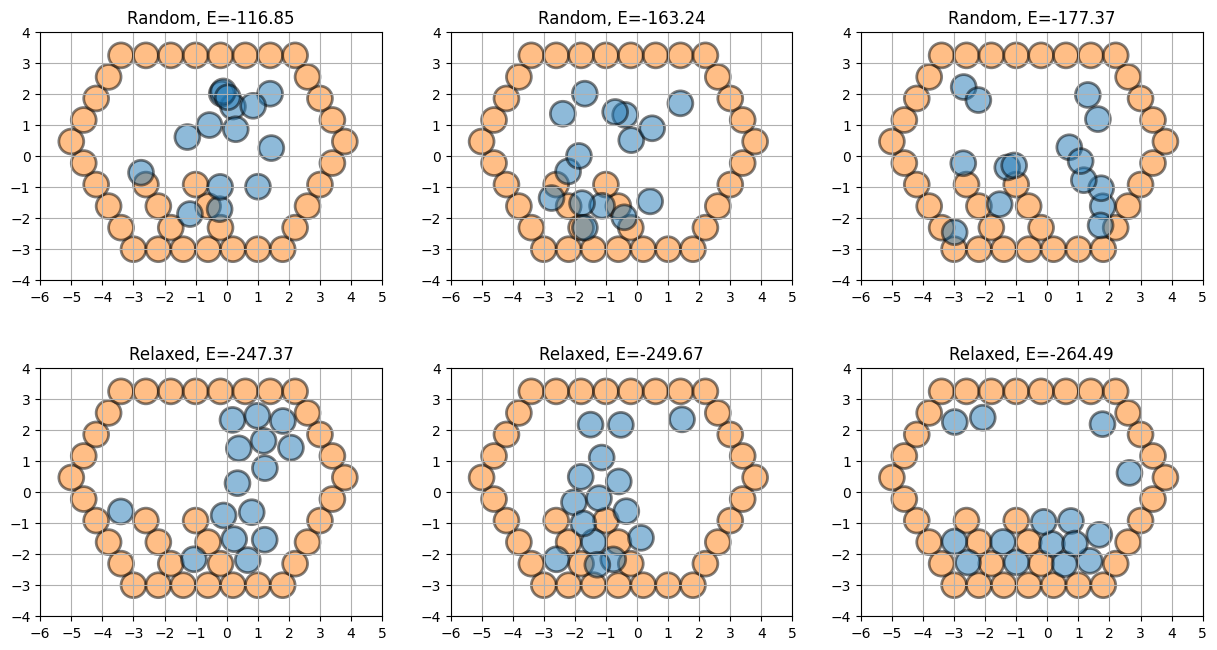

In [46]:
fig, axes = plt.subplots(2,3,figsize=(15,8))

for i in range(3):
    frame = create_initial_cluster(N=15)

    frame.title = 'Random'
    frame.draw(axes[0,i], size=0.4)
    nice_plot(axes[0,i])

    relax(frame)

    frame.title = 'Relaxed'
    frame.draw(axes[1,i], size=0.4)
    nice_plot(axes[1,i])

for ax in axes.flatten():
    ax.set_ylim(-4,4)
    ax.set_xlim(-6,5)

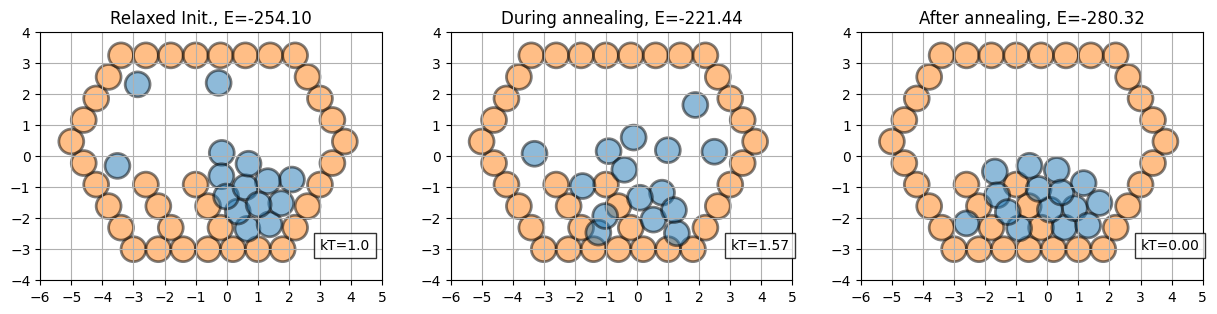

In [ ]:
def andrea_anderson_thermostat_sim(ac):
    sigma = np.sqrt(ac.kT) #/m is omitted, m=1
    # print(len(ac.pos))
    velocities = [[np.random.normal(0, sigma), np.random.normal(0, sigma)] for _ in range(len(ac.pos))]
    ac.set_velocities(velocities)

def velocity_verlet_sim(mdsys, N=50, timesteps=1):
    for steps in range(timesteps):
        for _ in range(N):
            dt = 0.01
            r = mdsys.get_positions()
            v = mdsys.get_velocities()
            a_t = mdsys.forces # assume m=1

            # 1. update position
            r += v*dt + 1/2*a_t*dt**2
            mdsys.set_positions(r)

            # 2. evaluate force and acceleration at new step
            a_t_dt = mdsys.forces # for harmonic osciallor F = -kx

            # 3. velocity update
            v += 1/2 * (a_t + a_t_dt)*dt
            mdsys.set_velocities(v)

fig, axes = plt.subplots(1,3,figsize=(15,4))

frame = create_initial_cluster(N=15, kT=1)
relax(frame)  # using line search (week 3)
frame.title = 'Relaxed Init.'
frame.draw(axes[0], size=0.4)
nice_plot(axes[0])
axes[0].text(3, -3, f'kT=1.0', bbox=dict(facecolor="white", alpha=0.8))

kT = 5
for i in range(100):
    frame.kT = kT
    # apply the thermostat
    andrea_anderson_thermostat_sim(frame)
    # do 50 constant energy steps
    velocity_verlet_sim(frame, N=50)
    kT *=0.9
    if i == 10:
        frame.title = 'During annealing'
        frame.draw(axes[1], size=0.4)
        nice_plot(axes[1])
        axes[1].text(3, -3, f'kT={kT:.2f}', bbox=dict(facecolor="white", alpha=0.8))

frame.title = 'After annealing'
frame.draw(axes[2], size=0.4)
nice_plot(axes[2])
axes[2].text(3, -3, f'kT={kT:.2f}', bbox=dict(facecolor="white", alpha=0.8))


for ax in axes.flatten():
    ax.set_ylim(-4,4)
    ax.set_xlim(-6,5)